# `GEA` tutorial: Gene expression dataset on Inflammatory Bowel Disease cohort

This notebook is used as a tutorial for creating sample-specific networks from gene expression data using a study from Inflammatory Bowel Disease (IBD) patients, and implementing Graph Explainable Attribution (GEA) to the learned embeddings from a Graph Neural Network model.

-----

**Data Description:**

- The dataset is composed of a study that reports the core ileal transcriptome in pediatric IBD patients and controls (BioProject accession: [PRJNA248469](https://www.ncbi.nlm.nih.gov/bioproject/248469)).
- Gene expression profiles from 303 samples of 204 Crohn's disease (CD) patients, 59 Ulcerative Colitis (UC) patients, and 40 healthy controls were analyzed.

**Goal:**

There are two main goals that follows this tutorial notebook: **(1)** generate sample-specific networks using a modified [LIONESS](https://link.springer.com/article/10.1186/s12885-019-6235-7) implementation, and **(2)** extract meaningful features from a trained GNN model using sparse autoencoders (SAE).

-----

## Loading IBD dataset

### Loading and filtering counts

`gea` has a series of functions to load all the data for constructing the sample-specific networks. Function `load_counts` at `dataloader` can be used to get a `pd.DataFrame` from a `.csv` file (or compatible):

In [1]:
from gea.dataloader import load_counts

# Load counts
counts_path = "data/tutorial-ibd-matrix.tsv"
raw_counts = load_counts(counts_path, delim = "\t", index_col = "Geneid")

# Evaluate
print(raw_counts.info())

<class 'pandas.core.frame.DataFrame'>
Index: 60664 entries, ENSG00000284662 to ENSG00000275405
Columns: 322 entries, SAMN03322967 to SAMN03323298
dtypes: int64(322)
memory usage: 149.5+ MB
None


We can see that the dataframe contains the Ensembl IDs for everything in the samples. We can use `ensembl_to_gene` from `utils` to get the IDs mapped to their corresponding gene symbol, as well as filtering other molecules (e.g. RNAs, pseudo-genes, non-coding genes, etc.):

In [2]:
from gea.utils import ensembl_to_gene

# Mapping Ensemlb IDs -> protein-coding genes (this may take a couple minutes)
gene_counts = ensembl_to_gene(raw_counts, species="human")

# Evaluate
print(f"After mapping {raw_counts.shape[0]} Ensembl IDs, only {gene_counts.shape[0]} genes remain.")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


35 input query terms found dup hits:	[('ENSG00000228044', 2), ('ENSG00000226506', 2), ('ENSG00000261600', 2), ('ENSG00000234162', 2), ('E
1209 input query terms found no hit:	['ENSG00000272482', 'ENSG00000224621', 'ENSG00000234166', 'ENSG00000225643', 'ENSG00000287400', 'ENS


After mapping 60664 Ensembl IDs, only 19465 genes remain.


We can proceed to filter counts based on variance and abundance using the function `filter_genes` from `preprocessing`:

In [3]:
from gea.preprocessing import filter_genes

filter_counts = filter_genes(gene_counts, cpm_threshold=1, min_frac=0.1, pct=0.1)

print(f"Filtered from {gene_counts.shape[0]} to {filter_counts.shape[0]} genes.")

Filtered from 19465 to 1511 genes.


### Loading metadata

We can use `load_metadata` from `dataloader` to get all relevant information from the experiments In this case, we have special interest in the cohorts of patients with IBD and our column of interest in this data would be `source_name`:

In [4]:
from gea.dataloader import load_metadata

# Load metadata
metadata_path = "data/tutorial-ibd-metadata.txt"
metadata = load_metadata(metadata_path, delim = ",", index_col=None)

# Evaluate
print(metadata.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Run                  322 non-null    object 
 1   age_at_diagnosis     322 non-null    float64
 2   Assay Type           322 non-null    object 
 3   AvgSpotLen           322 non-null    int64  
 4   Bases                322 non-null    int64  
 5   BioProject           322 non-null    object 
 6   BioSample            322 non-null    object 
 7   Bytes                322 non-null    int64  
 8   Center Name          322 non-null    object 
 9   Consent              322 non-null    object 
 10  DATASTORE filetype   322 non-null    object 
 11  DATASTORE provider   322 non-null    object 
 12  DATASTORE region     322 non-null    object 
 13  deep_ulcer           218 non-null    object 
 14  diagnosis            322 non-null    object 
 15  Experiment           322 non-null    obj

### Loading Protein-Protein Interaction network

As part of the modified LIONESS framework, previously known information about gene co-expression is given in the form of a Protein-Protein Interaction (PPI) network. For this, `load_ppi_network` from `dataloader` can be used to extract a PPI network from (STRING)[https://string-db.org] given a list of genes:

In [5]:
from gea.dataloader import load_ppi_network
from gea.utils import get_gene_list

# Get gene list from filtered data
gene_list = get_gene_list(filter_counts)

# Get PPI network
ppi_network = load_ppi_network(gene_list, species=9606)

# Evaluate
print(ppi_network.info())

Successfully retrieved PPI network!
Found 7829 interactions.
             stringId_A            stringId_B preferredName_A preferredName_B  \
0  9606.ENSP00000001146  9606.ENSP00000456609         CYP26B1           STRA6   
1  9606.ENSP00000001146  9606.ENSP00000310721         CYP26B1          CYP7B1   
2  9606.ENSP00000001146  9606.ENSP00000337224         CYP26B1            LRAT   
3  9606.ENSP00000001146  9606.ENSP00000320401         CYP26B1         UGT2B17   
4  9606.ENSP00000001146  9606.ENSP00000251566         CYP26B1          UGT2A3   

   ncbiTaxonId  score  nscore  fscore  pscore  ascore  escore  dscore  tscore  
0         9606  0.654     0.0     0.0   0.000   0.045   0.054    0.00   0.647  
1         9606  0.660     0.0     0.0   0.457   0.051   0.049    0.00   0.388  
2         9606  0.681     0.0     0.0   0.000   0.086   0.000    0.00   0.665  
3         9606  0.687     0.0     0.0   0.000   0.067   0.000    0.67   0.065  
4         9606  0.687     0.0     0.0   0.000   0.06

Now that we are using the PPI network as prior, we will prefer to only retain genes that appear on it. To do so, we can use `filter_ppi_nodes` in `preprocessing`:

In [6]:
from gea.preprocessing import filter_ppi_nodes

filter_counts_ppi = filter_ppi_nodes(filter_counts, ppi_network)

print(f"From {filter_counts.shape[0]} genes on the filtered counts dataframe, only {filter_counts_ppi.shape[0]} appear in the PPI network.")

From 1511 genes on the filtered counts dataframe, only 1165 appear in the PPI network.


### Loading Geneformer model

Usually Graph Neural Networks have no information on what exactly the node is if given without a flag. To overcome this, we are giving the model information of each gene by adding the Geneformer embedding as a feature in each node. We can load the Geneformer model by using `load_geneformer` from `dataloader`:

In [7]:
from gea.dataloader import load_geneformer

# Loading model and vocabulary
gf_model, gf_vocab = load_geneformer()

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ctheodoris/Geneformer
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Because we already have our counts dataframe at the last filtering step, we can call again `get_gene_list` from `utils` to get the embeddings we wish to extract from the model. To do so, `get_geneformer_embeddings` from `utils` is employed (the function randomize embeddings for genes that aren't found in model):

In [8]:
from gea.utils import get_geneformer_embeddings

# Get final gene list
gene_list = get_gene_list(filter_counts_ppi)

# Get Geneformer embeddings
gf_embeddings = get_geneformer_embeddings(gf_model, gf_vocab, gene_list)

Attempt 1/10 failed: Query ERROR: caught BioMart::Exception::Database: Could not connect to mysql database ensembl_mart_115: DBI connect('database=ensembl_mart_115;host=127.0.0.1;port=5316','ensro',...) failed: Can't connect to MySQL server on '127.0.0.1' (111) at /nfs/public/ro/ensweb/live/mart/www_115/biomart-perl/lib/BioMart/Configuration/DBLocation.pm line 98.

Attempt 2/10 failed: Query ERROR: caught BioMart::Exception::Database: Could not connect to mysql database ensembl_mart_115: DBI connect('database=ensembl_mart_115;host=127.0.0.1;port=5316','ensro',...) failed: Can't connect to MySQL server on '127.0.0.1' (111) at /nfs/public/ro/ensweb/live/mart/www_115/biomart-perl/lib/BioMart/Configuration/DBLocation.pm line 98.

Attempt 3/10 failed: Query ERROR: caught BioMart::Exception::Database: Could not connect to mysql database ensembl_mart_115: DBI connect('database=ensembl_mart_115;host=127.0.0.1;port=5316','ensro',...) failed: Can't connect to MySQL server on '127.0.0.1' (111) at

Extracting Geneformer embeddings: 100%|██████████| 1165/1165 [00:00<00:00, 42801.27it/s]

Found embeddings for 1154/1165 genes.


## Creating sample-specific networks

### Normalizing counts

For counts normalization `gea.preprocessing` has several functions that helps doing so. Right now the counts matrix should be in {columns: samples, rows: genes} format. We are going to transpose this during normalization to be compatible with other preprocessing methods. `normalize_counts` already applies this:

In [9]:
from gea.preprocessing import normalize_counts
# Normalize counts
# input format: pd.DataFrame({columns: samples, rows: genes})
# output format: pd.DataFrame({columns: genes, rows: samples})

norm_counts = normalize_counts(filter_counts_ppi)

# Evaluate
print(norm_counts.info())

<class 'pandas.core.frame.DataFrame'>
Index: 322 entries, SAMN03322967 to SAMN03323298
Columns: 1165 entries, TNFRSF4 to LOC102723407
dtypes: float64(1165)
memory usage: 2.9+ MB
None


### Gene co-expression matrix

Before building the gene co-expression matrix, we need to include any relevant metadata (e.g. phenotype group, treatment, etc.) using `merge_metadata` from `gea.preprocessing`. In this case the column of intereset is called `source_name`:

In [10]:
from gea.preprocessing import merge_metadata

joint_data = merge_metadata(norm_counts, metadata, counts_on="samples", meta_on="BioSample", meta_cols="source_name")

print(joint_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 322 entries, SAMN03322987 to SAMN03323235
Columns: 1166 entries, source_name to LOC102723407
dtypes: float64(1165), object(1)
memory usage: 2.9+ MB
None


For this specific study we are interested in only conserving IBD and control samples, therefore we can manually remove it with ease now that the dataframe is in a easy-to-handle format:

In [11]:
# Get indeces on dataframe with cohorts of interest
ibd_meta_index = joint_data["source_name"].str.contains("IBD|CD|UC")
# Filter
ibd_joint_data = joint_data[ibd_meta_index]
# Change phenotype name for readability
ibd_joint_data["source_name"] = ibd_joint_data["source_name"].str.split(",").str[-1].str.strip()
# Evaluate
print(ibd_joint_data.head())

             source_name   TNFRSF4     PLCH2      ESPN    SLC2A5     MMEL1  \
samples                                                                      
SAMN03322987          CD  3.901306  2.994765  8.351986  9.989918  3.303374   
SAMN03323176          CD  7.857138  3.871604  2.291736  7.634773  1.559846   
SAMN03323174          CD  6.623704  4.072887  8.019825  7.521163  2.649930   
SAMN03323029          CD  3.105348  4.343949  8.877234  9.656853  6.590481   
SAMN03323141          CD  6.896086  4.444778  3.819948  7.828881  2.097842   

                PIK3CD   IL22RA1     NR0B2    AKR7A3  ...   ADAMTS1      TFF2  \
samples                                               ...                       
SAMN03322987  6.953539  8.303615  6.392637  9.180478  ...  9.793746  5.637992   
SAMN03323176  9.429819  3.550314  0.000000  3.136338  ...  8.884080  0.000000   
SAMN03323174  8.307987  8.565749  5.559744  8.491024  ...  8.195638  5.518823   
SAMN03323029  6.846625  9.055966  5.174117  9.24

/tmp/ipykernel_1432895/2354479686.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibd_joint_data["source_name"] = ibd_joint_data["source_name"].str.split(",").str[-1].str.strip()


With this dataframe we can use `get_corr_matrix` from `gea.preprocessing` to build the gene co-expression matrices per group of interest:

In [12]:
from gea.preprocessing import get_corr_matrix

gene_corrs, grouped_data = get_corr_matrix(ibd_joint_data, group_by="source_name")

**Outputs:**

- `gene_corrs` is a list of `pd.DataFrame`, where each one is the co-expression matrix for its corresponding group.

- `grouped_data` is a list of `pd.DataFrame`, where each one is the normalized gene expression profile for its corresponding group. 

- In this case, there are 3 dataframes inside each list corresponding to the 2 IBD phenotypes (UC and CD), and the control cohort (non IBD).

### Z-space constrained LIONESS

-----

**Theoretical framework:**

LIONESS starts with the network $G$ built on all $N$ samples. For each sample $s$, the network built on all samples except that one is $G_{-s}$. Then, the sample-specific network $G_s$ is:

$$
G_{s} = N * G - (N-1) * G_{-s}
$$

If $G$ and $G_{-s}$ are correlation matrices, directly applying this may produce values outside $[-1,1]$, which can complicate interpretation. To avoid this, we will transform coefficients $r$ to Fisher-z space $\mathrm{atanh}(z)$. Because $\mathrm{atanh()}$ is a bijection from (-1, 1) -> $\mathbb{R}$ and $\mathrm{tanh()}$ is the inverse, any linear combination you form in z-space is guaranteed to map back to a value inside (-1, 1). Then:

$$
Z_{s} = N * Z - (N-1) * Z_{-s}
$$

$$
G_{s} = \mathrm{tanh}(Z_{s})
$$

For an extra layer of complexity, we have also added the PPI network as a prior to inform the network inference step of already-known interactions between genes. By doing this the framework discard any edge that isn't present in the network.

-----

**LIONESS on IBD dataset:**

The `lioness_ppi` function from `gea.preprocessing` applies our modified LIONESS algorithm to the gene co-expression matrices with the PPI network to infer sample-specific networks:

In [13]:
from gea.preprocessing import lioness_ppi

sample_networks = lioness_ppi(grouped_data, gene_corrs, ppi_network)

LIONESS samples (PPI filtered) for group 3/3: 100%|██████████| 59/59 [00:09<00:00,  6.04it/s]


-----

**Output format:**

`sample_networks` is a dictionary were keys are samples and the values are a `pd.DataFrame` with the following columns:

- `geneA`: the reference node (gene).
- `geneB`: the node that `geneA` is connected to.
- `weight`: the edge weight between `geneA` and `geneB`.

### Convert networks to PyG objects

To have the sample-specific network ready for training, `gene_networks_to_pyg` from `gea.preprocessing` transform the sample-specific networks to PyG objects. This function also adds the normalized counts of each gene in the network, as well as the Geneformer embeddings as a node feature. It also adds the biological group label the `y` variable for phenotype prediction task during training:

In [14]:
from gea.preprocessing import gene_networks_to_pyg

ibd_graphs = gene_networks_to_pyg(sample_networks, ibd_joint_data, gf_embeddings, bio_col="source_name")

Building PyG Data objects for sample-specific networks: 100%|██████████| 303/303 [01:02<00:00,  4.86it/s]


## Training GNN model

First we define the GNN model.

In [15]:
from gea.gea import RGCN, EdgePredictor, GraphClassifier, GNNModel
import torch

# Model parameters
in_dim = ibd_graphs[0].x.shape[1]
n_classes = 3  # CD, UC, and non IBD
d_z = 128  # latent space dimension

# Define RGCN model
rgcn = RGCN(in_channels=in_dim, hidden_channels=2 * d_z, latent_dim=d_z)

# Define edge predictor
edge_pred = EdgePredictor(in_dim=d_z)

# Define graph classifier
graph_class = GraphClassifier(in_dim=d_z, n_classes=n_classes)

# Define full GNN model
gnn = GNNModel(gnn=rgcn, classifier=graph_class, edge_predictor=edge_pred).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

We proceed to train the model

In [16]:
from torch_geometric.data import DataLoader
from gea.gea import train_gnn
import torch

# Used for training
train_loader = DataLoader(ibd_graphs, batch_size=32, shuffle=True)
# Used for evaluation
embed_loader = DataLoader(ibd_graphs, batch_size=32, shuffle=False)

# Training
train_gnn(
    model=gnn,
    train_loader=train_loader,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    epochs=100,
    lr=1e-3,
    w_l2=1e-4,
    w_classifier=1.0,
    w_edge_pred=0.5,
)

/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
Training GNN model: 100%|██████████| 1000/1000 [02:19<00:00,  7.19it/s, class_loss=0.0004, edge_loss=0.0193, epoch=99/101, total_loss=0.0198]


We can evaluate graph-level embeddings of the trained model with a UMAP:

Extracting Embeddings for UMAP...


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


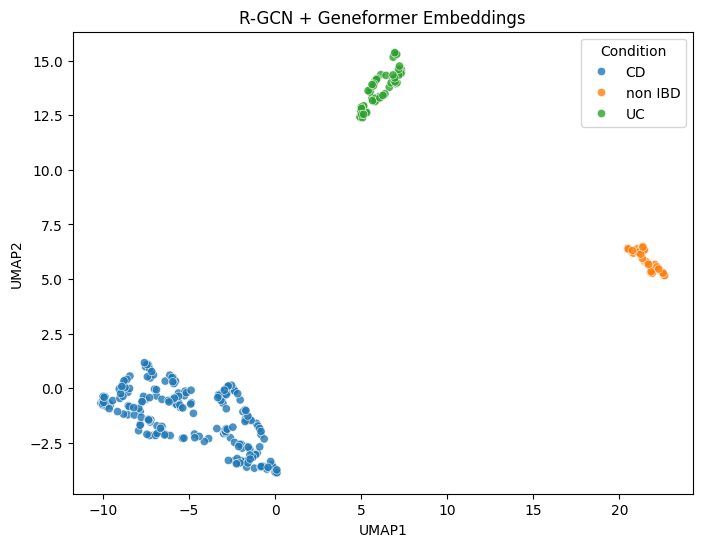

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import umap 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
label_names = ["CD", "UC", "non IBD"]

print("Extracting Embeddings for UMAP...")
gnn.eval()
embeddings = []
labels = []

with torch.no_grad():
    for batch in embed_loader:
        batch = batch.to(device)
        _, z_graph = gnn.encode(batch)
        embeddings.append(z_graph.cpu().numpy())
        labels.extend([label_names[y] for y in batch.y.cpu().numpy()])
        
X_emb = np.concatenate(embeddings, axis=0)

reducer = umap.UMAP(n_components=2, random_state=42)
umap_coords = reducer.fit_transform(X_emb)

df_plot = pd.DataFrame(umap_coords, columns=["UMAP1", "UMAP2"])
df_plot["Condition"] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x="UMAP1", y="UMAP2", hue="Condition", alpha=0.8)
plt.title("R-GCN + Geneformer Embeddings")
plt.show()

## GEA: Graph Explainable Attribution with Sparse Autoencoder

### Training graph-level SAE